# Lab-5: Implementation of RNN and LSTM:
## 2548514
### 1. Import Libraries:

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

### 2. Load Dataset:

In [ ]:
!wget https://www.gutenberg.org/files/100/100-0.txt -O shakespeare.txt

--2026-03-05 18:21:20--  https://www.gutenberg.org/files/100/100-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5422721 (5.2M) [text/plain]
Saving to: ‘shakespeare.txt’

shakespeare.txt     100%[===================>]   5.17M  6.69MB/s    in 0.8s    

2026-03-05 18:21:22 (6.69 MB/s) - ‘shakespeare.txt’ saved [5422721/5422721]



In [ ]:
text = open("shakespeare.txt").read().lower()

# Reduce dataset size
text = text[:20000]

print("Dataset length:", len(text))

Dataset length: 20000


### 3. Tokenization:

In [ ]:
vocab_size = 3000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts([text])

total_words = min(vocab_size, len(tokenizer.word_index)+1)

print("Vocabulary Size:", total_words)

Vocabulary Size: 1212


### 4. Create Input Sequences:

In [ ]:
tokens = tokenizer.texts_to_sequences([text])[0]

sequence_length = 5

input_sequences = []

for i in range(sequence_length, len(tokens)):
    seq = tokens[i-sequence_length:i+1]
    input_sequences.append(seq)

input_sequences = np.array(input_sequences)

print("Total sequences:", input_sequences.shape)

Total sequences: (3507, 6)


### 5. Split Input and Labels:

In [ ]:
X = input_sequences[:,:-1]
y = input_sequences[:,-1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print(X.shape, y.shape)

(3507, 5) (3507, 1212)


### 6. Build RNN model:

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=sequence_length),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 7. Train RNN Model:

In [ ]:
history_rnn = rnn_model.fit(
    X,
    y,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0108 - loss: 7.0160 - val_accuracy: 0.0057 - val_loss: 6.6452
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0327 - loss: 6.1504 - val_accuracy: 0.0256 - val_loss: 6.8101
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0390 - loss: 6.0820 - val_accuracy: 0.0256 - val_loss: 6.9539
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0421 - loss: 5.9870 - val_accuracy: 0.0256 - val_loss: 6.9822
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0412 - loss: 5.9534 - val_accuracy: 0.0228 - val_loss: 7.0457
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0396 - loss: 5.8472 - val_accuracy: 0.0285 - val_loss: 6.9364
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.0516 - loss: 5.7274 - val_accuracy: 0.0256 - val_loss: 6.9032
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0543 - loss: 5.5721 - val_accuracy: 0.0199 - v

### 8. Build LSTM Model:

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=sequence_length),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 9. Train LSTM Model:

In [ ]:
history_lstm = lstm_model.fit(
    X,
    y,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.0200 - loss: 7.0828 - val_accuracy: 0.0256 - val_loss: 6.7465
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0310 - loss: 6.3038 - val_accuracy: 0.0256 - val_loss: 6.7798
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0418 - loss: 6.0474 - val_accuracy: 0.0256 - val_loss: 6.9258
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0365 - loss: 6.0339 - val_accuracy: 0.0256 - val_loss: 7.1470
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0394 - loss: 5.9727 - val_accuracy: 0.0285 - val_loss: 7.2786
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0396 - loss: 5.9194 - val_accuracy: 0.0285 - val_loss: 7.3240
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.0348 - loss: 5.8991 - val_accuracy: 0.0256 - val_loss: 7.2896
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0404 - loss: 5.8675 - val_accuracy: 0.0256 - v

### 10. Text Generation Function:

In [ ]:
def generate_text(model, seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=sequence_length)

        predicted = np.argmax(model.predict(token_list), axis=-1)[0]

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                seed_text += " " + word
                break

    return seed_text

### 11. Test both models:

In [ ]:
seed = "to be or"

print("RNN Output:")
print(generate_text(rnn_model, seed, 5))

print("\nLSTM Output:")
print(generate_text(lstm_model, seed, 5))

RNN Output:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
to be or and and that that to

LSTM Output:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
to be or and and and and and


### 12. Training vs Validation Loss Graph:

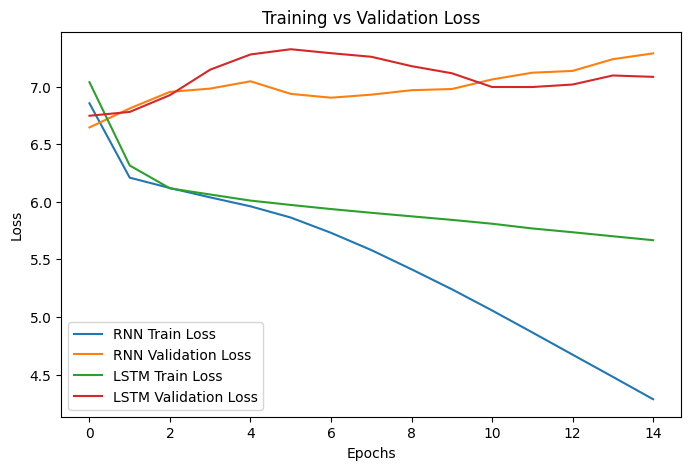

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='RNN Train Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss')

plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

### 13. Accuracy Comparison Graph:

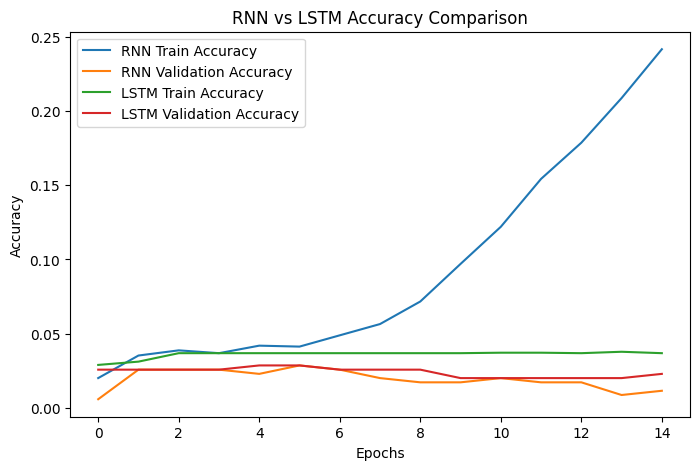

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['accuracy'], label='RNN Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Validation Accuracy')

plt.plot(history_lstm.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM Accuracy Comparison")
plt.legend()

plt.show()